In [ ]:
# Kaden Ellingson
# Random Forest Tornado Prediction 
# COSC 522 Group Project 

In [44]:
import pandas as pd

df = pd.read_csv('../data/raw/gsod_combined.csv')
df.head()

,DATE,LATITUDE,LONGITUDE,ELEVATION,TEMP,DEWP,SLP,STP,VISIB,WDSP,MXSPD,GUST,MAX,MIN,PRCP,TORNADO_LABEL
0,2021-01-01,34.294,-116.14722,610.5,51.7,22.9,1019.2,940.5,10.0,10.2,17.1,20.0,60.1,33.1,0.0,0
1,2021-01-02,34.294,-116.14722,610.5,44.1,19.1,1024.0,943.6,10.0,4.0,8.0,999.9,61.0,32.0,0.0,0
2,2021-01-03,34.294,-116.14722,610.5,46.6,23.9,1022.9,942.5,10.0,2.3,7.0,999.9,64.0,32.0,0.0,0
3,2021-01-04,34.294,-116.14722,610.5,47.7,29.2,1022.4,942.2,10.0,3.3,8.0,999.9,64.0,35.1,0.0,0
4,2021-01-05,34.294,-116.14722,610.5,54.4,34.3,1020.5,940.8,10.0,6.6,15.9,25.1,66.9,35.1,0.0,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2910868 entries, 0 to 2910867
Data columns (total 16 columns):
 #   Column         Dtype  
---  ------         -----  
 0   DATE           object 
 1   LATITUDE       float64
 2   LONGITUDE      float64
 3   ELEVATION      float64
 4   TEMP           float64
 5   DEWP           float64
 6   SLP            float64
 7   STP            float64
 8   VISIB          float64
 9   WDSP           float64
 10  MXSPD          float64
 11  GUST           float64
 12  MAX            float64
 13  MIN            float64
 14  PRCP           float64
 15  TORNADO_LABEL  int64  
dtypes: float64(14), int64(1), object(1)
memory usage: 355.3+ MB


In [46]:
df.describe()

,LATITUDE,LONGITUDE,ELEVATION,TEMP,DEWP,SLP,STP,VISIB,WDSP,MXSPD,GUST,MAX,MIN,PRCP,TORNADO_LABEL
count,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06,2.910868e+06
mean,3.884376e+01,-9.329792e+01,3.874516e+02,5.600092e+01,1.284152e+03,4.634124e+03,7.102228e+02,2.260745e+02,6.570011e+01,7.974803e+01,4.800074e+02,7.751379e+01,4.968534e+01,8.507884e+00,5.565350e-05
std,6.038476e+00,1.464900e+01,5.245342e+02,1.943379e+01,3.288888e+03,4.405961e+03,4.249904e+02,4.094920e+02,2.355132e+02,2.474278e+02,4.875651e+02,3.129749e+02,1.950615e+02,2.779804e+01,7.459921e-03
min,2.405000e+01,-1.249167e+02,-3.600000e+01,-4.240000e+01,-9.220000e+01,9.044000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01,9.700000e+00,-3.780000e+01,-4.720000e+01,0.000000e+00,0.000000e+00
25%,3.420012e+01,-1.025487e+02,5.430000e+01,4.240000e+01,3.090000e+01,1.014900e+03,2.200000e+01,9.500000e+00,3.700000e+00,8.900000e+00,2.100000e+01,5.400000e+01,3.200000e+01,0.000000e+00,0.000000e+00
50%,3.916250e+01,-9.116667e+01,2.082000e+02,5.850000e+01,4.860000e+01,1.022800e+03,9.725000e+02,1.000000e+01,6.000000e+00,1.300000e+01,3.500000e+01,7.110000e+01,4.750000e+01,0.000000e+00,0.000000e+00
75%,4.364244e+01,-8.180000e+01,4.017000e+02,7.140000e+01,6.540000e+01,9.999900e+03,9.973000e+02,1.000000e+01,9.000000e+00,1.810000e+01,9.999000e+02,8.370000e+01,6.100000e+01,2.000000e-02,0.000000e+00
max,4.950000e+01,-6.653333e+01,4.113300e+03,1.100000e+02,9.999900e+03,9.999900e+03,9.999000e+02,9.999000e+02,9.999000e+02,9.999000e+02,9.999000e+02,9.999900e+03,9.999900e+03,9.999000e+01,1.000000e+00


In [47]:
df['TORNADO_LABEL'].value_counts()

TORNADO_LABEL
0    2910706
1        162
Name: count, dtype: int64

In [48]:
df.replace(999.9, pd.NA, inplace=True)

In [49]:
df.dropna(inplace=True)

In [50]:
import pandas as pd
from sklearn.utils import resample

df = pd.read_csv('../data/raw/gsod_combined.csv')

# Replace NOAA placeholder values, but don't instantly drop every row with any missing field
df = df.replace({999.9: pd.NA, 9999.9: pd.NA, 999.99: pd.NA})

features = [
    'LATITUDE', 'LONGITUDE', 'ELEVATION', 'TEMP', 'DEWP',
    'SLP', 'STP', 'VISIB', 'WDSP', 'MXSPD',
    'GUST', 'MAX', 'MIN', 'PRCP'
]

# Fill missing feature values with column medians instead of dropping rows
df[features] = df[features].apply(pd.to_numeric, errors='coerce')
df[features] = df[features].fillna(df[features].median())

print(df['TORNADO_LABEL'].value_counts())

TORNADO_LABEL
0    2910706
1        162
Name: count, dtype: int64


In [51]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['TORNADO_LABEL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:

train_df = X_train.copy()
train_df['TORNADO_LABEL'] = y_train

df_majority = train_df[train_df.TORNADO_LABEL == 0]
df_minority = train_df[train_df.TORNADO_LABEL == 1]

print("Before balancing:")
print(train_df['TORNADO_LABEL'].value_counts())

df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

df_train_balanced = pd.concat([df_majority_downsampled, df_minority])

print("After balancing:")
print(df_train_balanced['TORNADO_LABEL'].value_counts())

X_train = df_train_balanced[features]
y_train = df_train_balanced['TORNADO_LABEL']

Before balancing:
TORNADO_LABEL
0    2328564
1        130
Name: count, dtype: int64
After balancing:
TORNADO_LABEL
0    130
1    130
Name: count, dtype: int64


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[506949  75193]
 [     7     25]]
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    582142
           1       0.00      0.78      0.00        32

    accuracy                           0.87    582174
   macro avg       0.50      0.83      0.47    582174
weighted avg       1.00      0.87      0.93    582174



In [54]:
feature_importance = pd.Series(rf.feature_importances_, index=features)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

DEWP         0.150135
LATITUDE     0.134182
ELEVATION    0.125740
SLP          0.106928
MIN          0.074334
TEMP         0.068487
LONGITUDE    0.061114
MAX          0.060432
VISIB        0.051215
WDSP         0.037939
STP          0.035057
GUST         0.034674
MXSPD        0.034062
PRCP         0.025701
dtype: float64


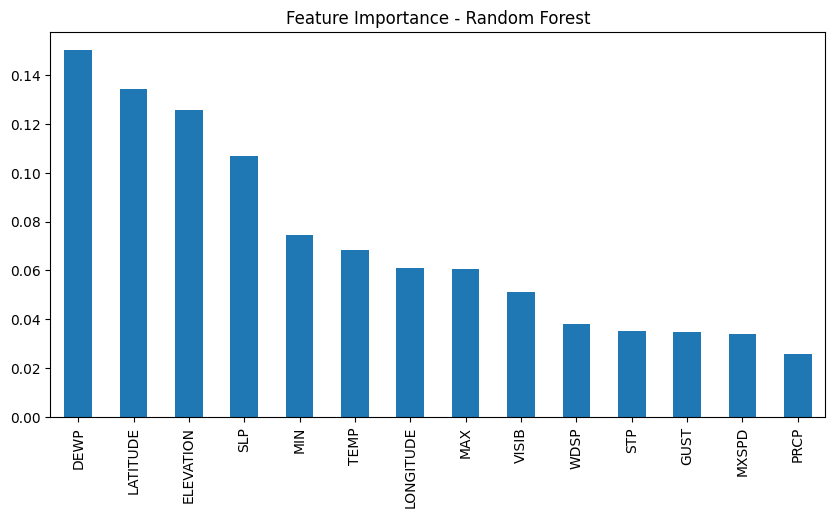

: 

In [ ]:
import matplotlib.pyplot as plt

feature_importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Random Forest")
plt.show()